In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [ ]:
import torch
import pandas as pd
import numpy as np
import re
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import BertForSequenceClassification, BertTokenizer
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

Используем устройство: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1: 100%|██████████| 2500/2500 [

Epoch 1: Train Loss: 0.3026, Train Acc: 0.8684 | Val Loss: 0.2481, Val Acc: 0.8970


Epoch 2: 100%|██████████| 2500/2500 [15:44<00:00,  2.65it/s]


Epoch 2: Train Loss: 0.1747, Train Acc: 0.9320 | Val Loss: 0.2714, Val Acc: 0.9016


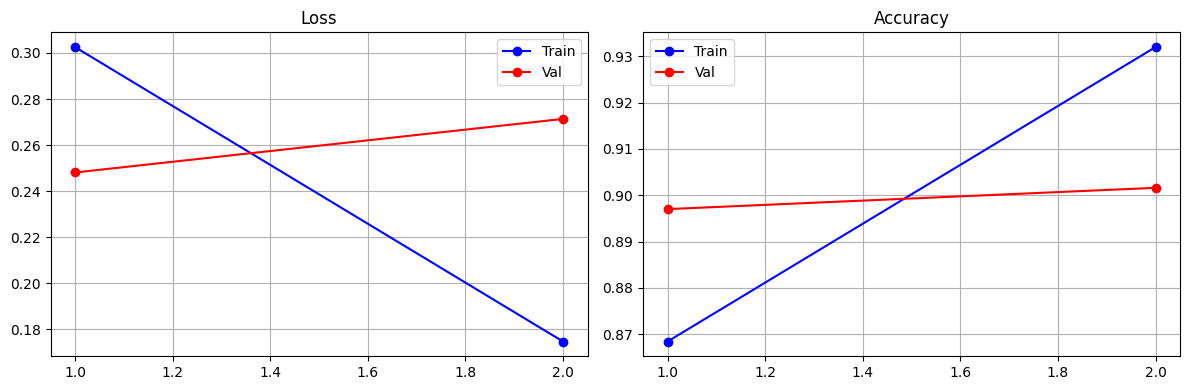


Accuracy: 0.9016
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      4961
    Positive       0.89      0.92      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000


Тест: POSITIVE


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}")

# 1. ПОДГОТОВКА ДАННЫХ


df = pd.read_csv("IMDB Dataset.csv", on_bad_lines='skip')
df['review'] = df['review'].apply(lambda x: re.sub(r'<.*?>', '', str(x)).lower().strip())
df = df[df['review'] != ''].reset_index(drop=True)
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['review'].tolist(), df['sentiment'].tolist(), test_size=0.2, random_state=42
)

# 2. ТОКЕНИЗАЦИЯ
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_enc = tokenizer(train_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')
test_enc = tokenizer(test_texts, truncation=True, padding=True, max_length=128, return_tensors='pt')

# 3. DATASET
class CustomDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx]
        }, torch.tensor(self.labels[idx], dtype=torch.long)

    def __len__(self):
        return len(self.labels)

train_dataset = CustomDataset(train_enc, train_labels)
test_dataset = CustomDataset(test_enc, test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 4. МОДЕЛЬ (ГОТОВАЯ ДЛЯ КЛАССИФИКАЦИИ)
print("Загрузка модели")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2).to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)

# 5. ОБУЧЕНИЕ
epochs = 2
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # Train
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        inputs, labels = batch
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(outputs.logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_losses.append(train_loss/len(train_loader))
    train_accs.append(train_correct/train_total)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for batch in test_loader:
            inputs, labels = batch
            input_ids = inputs['input_ids'].to(device)
            attention_mask = inputs['attention_mask'].to(device)
            labels = labels.to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)

            val_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_loss/len(test_loader))
    val_accs.append(val_correct/val_total)

    print(f'Epoch {epoch+1}: Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}')

# 6. ГРАФИКИ
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(range(1, epochs+1), train_losses, 'b-o', label='Train')
plt.plot(range(1, epochs+1), val_losses, 'r-o', label='Val')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.subplot(122)
plt.plot(range(1, epochs+1), train_accs, 'b-o', label='Train')
plt.plot(range(1, epochs+1), val_accs, 'r-o', label='Val')
plt.title('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 7. ФИНАЛЬНАЯ ОЦЕНКА
model.eval()
preds, true = [], []
with torch.no_grad():
    for batch in test_loader:
        inputs, labels = batch
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
        true.extend(labels.numpy())

print(f"\nAccuracy: {accuracy_score(true, preds):.4f}")
print(classification_report(true, preds, target_names=['Negative', 'Positive']))

# 8. ТЕСТ
def predict(text):
    model.eval()
    enc = tokenizer(text, truncation=True, padding=True, max_length=128, return_tensors='pt')
    with torch.no_grad():
        out = model(enc['input_ids'].to(device), enc['attention_mask'].to(device))
    return 'POSITIVE' if torch.argmax(out.logits).item() == 1 else 'NEGATIVE'

print(f"\nТест: {predict('This movie is great!')}")

In [ ]:
# 9. ТЕСТ
def predict(text):
    model.eval()
    enc = tokenizer(text, truncation=True, padding=True, max_length=128, return_tensors='pt')
    with torch.no_grad():
        out = model(enc['input_ids'].to(device), enc['attention_mask'].to(device))
    return 'POSITIVE' if torch.argmax(out.logits).item() == 1 else 'NEGATIVE'

print(f"\nТест: {predict('This movie is boring')}")


Тест: NEGATIVE


Полученная точность за 2 эпохи Accuracy: 0.9016